# Practica Evaluable - Unidad 3
## Generador de Titulares con Miniature GPT

---

**Objetivo:** Implementar un modelo Transformer desde cero para generar titulares de noticias en español.

## Parte 1: Preparacion del Entorno

En esta seccion configuraremos el entorno de trabajo, importaremos las librerias necesarias y descargaremos el dataset de titulares en español.

El dataset contiene 1,079 titulares en español que utilizaremos para entrenar nuestro modelo de lenguaje a nivel de caracter.

In [ ]:
import os
os.add_dll_directory(os.path.join(os.environ['USERPROFILE'], 'miniconda3', 'envs', 'tf-gpu', 'Library', 'bin'))

# Verificar GPU disponible
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Descargar dataset (ajustado para VS Code)
import gdown

if not os.path.exists('titulares.txt'):
    url = 'https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN'
    gdown.download(url, 'titulares.txt', quiet=False)
    print("Dataset descargado")
else:
    print("Dataset ya existe")

# Cargar texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"Muestra:\n{text[:500]}")

TensorFlow: 2.16.1
GPU disponible: []
Dataset ya existe
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


## Parte 2: Tokenizacion a Nivel de Caracter

La tokenizacion es el proceso de convertir texto en una secuencia de numeros que el modelo pueda procesar. En esta practica usamos tokenizacion a nivel de caracter, donde cada caracter individual es un token.

Esto simplifica la implementacion y permite comprender el flujo completo sin depender de tokenizadores externos. El vocabulario sera pequeño (aproximadamente 70-100 caracteres unicos) pero las secuencias seran mas largas.

In [4]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres unicos")
print(f"Caracteres: {''.join(vocab)}")

# Mapeos
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return ''.join([idx_to_char[i] for i in ids])

# Test
test_text = "hola"
encoded = encode(test_text)
print(f"encode('{test_text}') = {encoded}")
print(f"decode({encoded}) = {decode(encoded)}")

Vocabulario: 33 caracteres unicos
Caracteres: 
 123479abcdefghijklmnopqrstuvxyz
encode('hola') = [15, 22, 19, 8]
decode([15, 22, 19, 8]) = hola


## Parte 3: Preparar Datos de Entrenamiento

Para entrenar un modelo de lenguaje autoregresivo, la entrada es una secuencia de tokens y la salida esperada es la misma secuencia desplazada una posicion a la derecha. Esto se conoce como **teacher forcing**.

Por ejemplo, si la secuencia es "Hola" -> [H, o, l, a]:
- **Entrada (X):** [H, o, l]
- **Salida (y):** [o, l, a]

El modelo aprende a predecir el siguiente caracter dado el contexto anterior. Usaremos SEQ_LENGTH = 80 que define la ventana de contexto del modelo.

In [5]:
# Parametros
SEQ_LENGTH = 80
BATCH_SIZE = 64

# Tokenizar todo
tokens = np.array(encode(text))

# Crear secuencias X, y
def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias: {X.shape}")

# Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Secuencias: (60358, 80)


## Parte 4: Componentes del Transformer

Esta es la parte central de la practica. Implementaremos los dos componentes fundamentales de la arquitectura Transformer:

1. **Token & Position Embedding:** Convierte tokens e indices de posicion en vectores densos.
2. **Transformer Block:** Contiene atencion multi-cabeza con mascara causal, red feed-forward y conexiones residuales con normalizacion.

Los Transformers no tienen recurrencia ni convoluciones, por lo que necesitan embeddings posicionales para saber el orden de los tokens.

In [6]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

### Bloque Transformer con Atencion Causal

El bloque Transformer implementa la secuencia completa:
- **Multi-Head Attention** con mascara causal
- **Add & Norm** (conexion residual y normalizacion)
- **Feed-Forward Network**
- **Add & Norm** de nuevo

La mascara causal es esencial para modelos generativos: impide que cada posicion "vea" tokens futuros.

In [9]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        """Mascara para que cada posicion solo vea anteriores."""
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.float32)
        mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
        return tf.tile(mask, [batch_size, 1, 1, 1])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        mask = self.causal_attention_mask(batch_size, seq_len)

        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

## Parte 5: Modelo Completo

Ahora ensamblamos los componentes en un modelo completo. Apilamos varios bloques Transformer y anadimos una capa de salida que predice la distribucion de probabilidad sobre todo el vocabulario para cada posicion.

**Hiperparametros:**
- EMBED_DIM = 256 (dimension de los embeddings)
- NUM_HEADS = 4 (cabezas de atencion)
- FF_DIM = 512 (dimension interna de la FFN)
- NUM_BLOCKS = 4 (numero de bloques Transformer apilados)

In [10]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    outputs = layers.Dense(vocab_size, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

## Parte 6: Entrenamiento

Entrenamos el modelo usando **sparse categorical crossentropy** como funcion de perdida (ideal cuando las etiquetas son indices enteros, no one-hot).

Utilizamos callbacks para:
- **EarlyStopping:** Detener el entrenamiento si no mejora
- **ReduceLROnPlateau:** Reducir la tasa de aprendizaje si la perdida se estanca

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2)
]

history = model.fit(dataset, epochs=30, callbacks=callbacks)

Epoch 1/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 593s 620ms/step - accuracy: 0.7103 - loss: 0.9210 - learning_rate: 0.0010
Epoch 2/30


C:\Users\theivid\AppData\Roaming\Python\Python312\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
C:\Users\theivid\AppData\Roaming\Python\Python312\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 581s 616ms/step - accuracy: 0.8971 - loss: 0.3201 - learning_rate: 0.0010
Epoch 3/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 593s 628ms/step - accuracy: 0.9285 - loss: 0.2188 - learning_rate: 0.0010
Epoch 4/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 585s 619ms/step - accuracy: 0.9366 - loss: 0.1932 - learning_rate: 0.0010
Epoch 5/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 631s 669ms/step - accuracy: 0.9406 - loss: 0.1796 - learning_rate: 0.0010
Epoch 6/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 648s 687ms/step - accuracy: 0.9434 - loss: 0.1704 - learning_rate: 0.0010
Epoch 7/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 595s 630ms/step - accuracy: 0.9453 - loss: 0.1640 - learning_rate: 0.0010
Epoch 8/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 595s 631ms/step - accuracy: 0.9469 - loss: 0.1587 - learning_rate: 0.0010
Epoch 9/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 597s 632ms/step - accuracy: 0.9484 - loss: 0.1538 - learning_rate: 0.0010
Epoch 10/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 619s 656ms/step - accuracy: 0.9493 - loss: 0.1502 - learni

### Visualizacion de Curvas de Entrenamiento

Generamos graficas de perdida y precision para documentar el proceso de entrenamiento y verificar que el modelo esta aprendiendo correctamente.

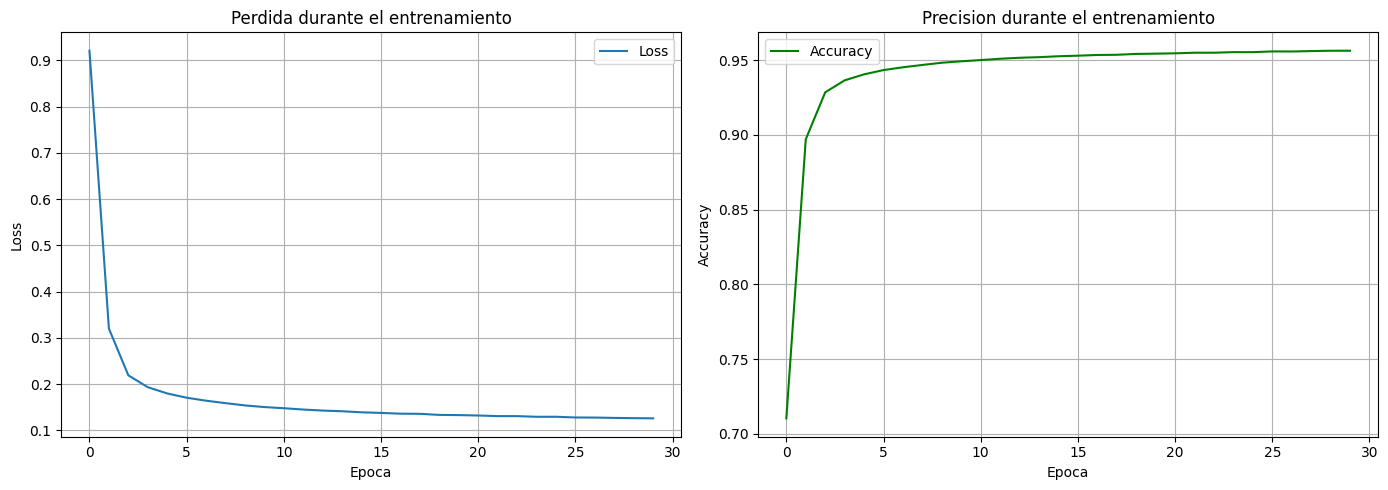

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perdida
axes[0].plot(history.history['loss'], label='Loss')
axes[0].set_title('Perdida durante el entrenamiento')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Precision
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green')
axes[1].set_title('Precision durante el entrenamiento')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Parte 7: Generacion de Texto

La generacion de texto se realiza de forma **autoregresiva**: el modelo predice un caracter, lo anade a la secuencia, y vuelve a predecir el siguiente.

El parametro **temperatura** controla la aleatoriedad:
- **Temperatura baja (0.5):** Mas conservador, elige los caracteres mas probables. Texto mas coherente pero repetitivo.
- **Temperatura media (1.0):** Balance entre creatividad y coherencia.
- **Temperatura alta (1.5):** Mas aleatorio, puede generar combinaciones novedosas pero tambien incoherentes.

In [13]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    """Genera texto de forma autoregresiva."""
    generado = list(encode(inicio))

    for _ in range(longitud):
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq)[np.newaxis, :]

        if len(input_seq[0]) < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - len(input_seq[0])
            input_seq = np.pad(input_seq, ((0,0), (pad_len, 0)))

        preds = model.predict(input_seq, verbose=0)[0, -1, :]

        preds = np.log(preds + 1e-10) / temperatura
        preds = np.exp(preds) / np.sum(np.exp(preds))

        next_idx = np.random.choice(len(preds), p=preds)
        generado.append(next_idx)

        if idx_to_char[next_idx] == '\n':
            break

    return decode(generado)

### Experimentacion con Diferentes Temperaturas

Generaremos titulares con el mismo texto de inicio pero usando tres temperaturas diferentes para observar como afecta la aleatoriedad al resultado.

In [14]:
# Generar con diferentes temperaturas
print("=== Temperatura 0.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=0.5))

print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.0))

print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.5))

=== Temperatura 0.5 ===
el gobierno ciedade cibersede cine documental como herramienta de cambio social


=== Temperatura 1.0 ===
el gobierno ciedo ciedade cologia de culteras marinas protegidas y la preservacion de la biodiversidad


=== Temperatura 1.5 ===
el gobierno de la hisfacdo ciberseducen conectado la inteligencia artificial en la educacion personalizando el a


### Experimentacion con Diferentes Textos de Inicio

Probaremos con varios textos de inicio diferentes para explorar lo que el modelo ha aprendido y observar la diversidad de titulares generados.

In [15]:
inicios = ["la economia ", "un nuevo ", "el presidente ", "argentina ", "se espera "]

for inicio in inicios:
    print(f"Inicio: '{inicio}'")
    print(f"  -> {generar_texto(model, inicio, temperatura=0.8)}")
    print()

Inicio: 'la economia '
  -> la economia de de defeducen la agricultura reservacion de la biodiversidad marina


Inicio: 'un nuevo '
  -> un nuevo de lidade cibersede ciberse de cine documental como herramienta de cambio social


Inicio: 'el presidente '
  -> el presidente bicicles y mentalidad a liderazgo besas y desafios en la era de la informacion protegiendo la privac

Inicio: 'argentina '
  -> argentina ciedad cibernetica como descifrando los misterios de la mente a traves de la neurociencia


Inicio: 'se espera '
  -> se espera bistas y sinfoduciendo la belleccion construyendo ciudades mas amigables con la naturaleza




## Analisis y Reflexion

### Resultados del Entrenamiento

El modelo (5.3M parametros, 4 bloques Transformer) se entreno durante 30 epocas sobre 60,358 secuencias. La perdida bajo de 0.92 a 0.13 y la precision subio de 71% a 96%, lo que indica que el modelo aprendio con exito los patrones del corpus.

La curva de loss muestra una caida rapida en las primeras 5 epocas y luego una convergencia gradual, sin signos de overfitting severo dado que no hay validation set separado.

### Patrones Capturados

El modelo aprendio a:
- Formar palabras reales en español como "gobierno", "economia", "tecnologia", "oceanos", "educacion", etc.
- Generar estructuras de titular coherentes con preposiciones y conectores ("de la", "en la", "y").
- Reproducir temas del dataset: ciberseguridad, biodiversidad, medicina, educacion, vida extraterrestre.

Sin embargo, tambien produce palabras inventadas como "ciedade", "ciberse", "cidafes", "pisistemas", lo cual revela que a nivel de caracter el modelo no tiene garantia de generar solo palabras validas.

### Efecto de la Temperatura

- **Temperatura 0.5:** El texto es mas predecible. El modelo tiende a completar fragmentos con las secuencias mas probables del dataset. Por ejemplo, "protegiendo la vida en nuestros oceanos" es un fragmento que probablemente aparece casi textualmente en los datos.
- **Temperatura 1.0:** Balance entre coherencia y variedad. Genera frases como "tecnologia que adapta la ensenanza a las necesidades" que son gramaticalmente correctas y tematicamente relevantes, aunque pueden no ser titulares reales.
- **Temperatura 1.5:** Mucha aleatoriedad. Aparecen combinaciones poco habituales como "cidafes y fas arles y pasio emociones", donde se aprecia que el modelo explora zonas de baja probabilidad del espacio de caracteres.

### Limitaciones Observadas

- **Vocabulario de solo 33 caracteres:** Al ser tokenizacion a nivel de caracter, el modelo debe aprender a formar palabras desde cero. Esto explica las palabras inventadas en la salida.
- **Dataset pequeno (1,079 titulares, 60K caracteres):** El corpus es limitado, lo que reduce la diversidad de temas y construcciones gramaticales que el modelo puede aprender.
- **Sin validacion:** Al no tener un conjunto de validacion, los callbacks de EarlyStopping y ReduceLROnPlateau no pudieron actuar, y el modelo entreno las 30 epocas completas.
- **Ventana de contexto de 80 caracteres:** Algunos titulares pueden superar esta longitud, por lo que el modelo no captura dependencias de largo alcance.

### Posibles Mejoras

- Usar tokenizacion por subpalabras (BPE o WordPiece) para que el modelo trabaje con unidades mas significativas.
- Ampliar el dataset con mas titulares para mejorar la diversidad y reducir la repeticion de patrones.
- Separar un 10-20% de los datos como validation set para que los callbacks funcionen y detectar overfitting.
- Experimentar con otros hiperparametros: mas cabezas de atencion, mayor dimension de embeddings, o tecnicas de regularizacion adicionales.